# 03a – Hungarian DEPT Similarity: `ppm_tolerance` Parameter Optimisation

This notebook sweeps the `ppm_tolerance` parameter of the Hungarian peak-matching
method and evaluates Hits@K retrieval performance on the experimental NMRShiftDB2
validation set.

## 0 · Imports

In [1]:
import ast
import os

# Silence tqdm progress bars (incl. the library prefilter's) — the parallel
# sweep runs in a few minutes, so the bars add noise without much value.
os.environ["TQDM_DISABLE"] = "1"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from dept_similarity.constants import PROCESSED_DATA_DIR, RESULTS_DIR
from dept_similarity.prepare import prefilter_pairs_by_peak_overlap
from dept_similarity.spectral_matching import (
    align_dept_peaks_hungarian,
    cosine_from_alignment,
    jaccard_from_alignment,
)

tqdm.pandas()

## 1 · Load data

Loads `library_data.parquet` and `experimental_validation_set.parquet`, normalises
`signed_shifts` to float32 arrays, then builds a reproducible random query subset
from unique molecules (`QUERY_SUBSET_SIZE`, `RANDOM_SEED`).

In [2]:
library_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet")
query_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")


def _to_float_array(v):
    if isinstance(v, np.ndarray):
        return v.astype(np.float32, copy=False)
    if isinstance(v, list):
        return np.asarray(v, dtype=np.float32)
    if isinstance(v, str):
        v = v.strip()
        if not v:
            return np.asarray([], dtype=np.float32)
        try:
            parsed = ast.literal_eval(v)
        except (ValueError, SyntaxError):
            parsed = []
        return np.asarray(parsed, dtype=np.float32)
    if pd.isna(v):
        return np.asarray([], dtype=np.float32)
    return np.asarray(v, dtype=np.float32)


library_spectra_df["signed_shifts"] = library_spectra_df["signed_shifts"].map(_to_float_array)
query_spectra_df["signed_shifts"] = query_spectra_df["signed_shifts"].map(_to_float_array)

# None → use the full validation set (all unique-molecule queries). Set an int to subsample.
QUERY_SUBSET_SIZE = None
RANDOM_SEED = 42

query_unique_df = query_spectra_df.drop_duplicates(subset=["inchikey"]).copy()
if QUERY_SUBSET_SIZE is not None:
    if len(query_unique_df) < QUERY_SUBSET_SIZE:
        raise ValueError(
            f"Need at least {QUERY_SUBSET_SIZE} unique query molecules, found {len(query_unique_df)}"
        )
    query_spectra_df = query_unique_df.sample(
        n=QUERY_SUBSET_SIZE, random_state=RANDOM_SEED
    ).reset_index(drop=True)
else:
    query_spectra_df = query_unique_df.reset_index(drop=True)

print(
    {
        "library_rows": len(library_spectra_df),
        "query_rows": len(query_spectra_df),
        "query_unique_inchikeys": int(query_spectra_df["inchikey"].nunique()),
        "random_seed": RANDOM_SEED,
    }
)

{'library_rows': 455289, 'query_rows': 648, 'query_unique_inchikeys': 648, 'random_seed': 42}


## 2 · Pre-filter candidate pairs

Same peak-overlap pre-filter as `03_similarity_metrics.ipynb`.

In [3]:
all_pairs_dict = prefilter_pairs_by_peak_overlap(
    query_spectra_df,
    library_spectra_df,
)

print(f"Total query molecules: {len(all_pairs_dict)}")

Total query molecules: 648


## 3 · Pre-load peak arrays

Unlike the Gaussian sweep, the Hungarian encoding is the raw signed peak array
(independent of `ppm_tolerance`).  We load all query and library peak arrays
into memory once here and reuse them across every tolerance value, avoiding
repeated DataFrame lookups in the inner loop.

In [4]:
query_ids = query_spectra_df["compound_id"].tolist()
query_peaks = query_spectra_df.set_index("compound_id")["signed_shifts"].to_dict()
library_peaks = library_spectra_df.set_index("compound_id")["signed_shifts"].to_dict()

query_inchikey = query_spectra_df.set_index("compound_id")["inchikey14"].to_dict()
# Support both column name conventions
_lib_ik_col = "inchikey14" if "inchikey14" in library_spectra_df.columns else "inchikey14"
library_inchikey = library_spectra_df.set_index("compound_id")[_lib_ik_col].to_dict()

print(f"Query peak arrays loaded   : {len(query_peaks)}")
print(f"Library peak arrays loaded : {len(library_peaks)}")

Query peak arrays loaded   : 648
Library peak arrays loaded : 455289


## 4 · `ppm_tolerance` sweep configuration

Edit `TOL_VALUES` to add / remove candidates.  The current range spans
tight sub-peak (0.5 ppm) to permissive (8.0 ppm) regimes.

- `match_multiplicity=True` is held fixed: only same-type peak pairs (CH/CH₃–CH/CH₃
  or CH₂–CH₂) are eligible.  Set to `False` to ablate multiplicity gating.
- `N_WORKERS` controls the joblib **process** pool used for the per-query alignment
  work.  The Hungarian alignment runs a numba `@njit` kernel that holds the GIL, so
  a thread pool cannot run alignments concurrently — a process pool sidesteps the GIL
  and scales near-linearly up to the number of cores.  Lower `N_WORKERS` to be
  friendly on a shared box.

In [5]:
# --- Sweep parameters ---------------------------------------------------
TOL_VALUES: list[float] = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]
K_VALUES: list[int] = [1, 5, 10]
MATCH_MULTIPLICITY: bool = True
MIN_MATCHED_PEAKS: int = 1
N_WORKERS: int = os.cpu_count() or 4

# Output root: <RESULTS_DIR>/optimization/hungarian/
OPT_DIR = Path(RESULTS_DIR) / "optimization" / "hungarian"
OPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ppm_tolerance values : {TOL_VALUES}")
print(f"Hits@K values        : {K_VALUES}")
print(f"match_multiplicity   : {MATCH_MULTIPLICITY}")
print(f"Worker threads       : {N_WORKERS}")
print(f"Output directory     : {OPT_DIR}")

ppm_tolerance values : [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]
Hits@K values        : [1, 5, 10]
match_multiplicity   : True
Worker threads       : 96
Output directory     : ../data/results/optimization/hungarian


## 5 · Run the sweep

For each `ppm_tolerance`:
1. Score all query–candidate pairs via `align_dept_peaks_hungarian`.
   Both `cosine` and `jaccard` are derived from the same `AlignmentResult`
   at zero extra alignment cost.
2. A joblib **fork-based** process pool (`backend="multiprocessing"`) parallelises
   the per-query alignment work across cores.  Workers inherit the big
   `library_peaks` / `query_peaks` dicts copy-on-write, so only the query id is
   sent to each task — no per-task data pickling, so all cores stay busy.  Ties
   are broken with a stable sort so ranks match the serial version exactly.
3. The rank of the true library match (by InChIKey14) is recorded for each query.
4. Results are saved per tolerance/metric/k and a checkpointing guard skips
   tolerances whose output files already exist.

In [6]:
METRICS = ["cosine", "jaccard"]

# Maps metric name → scoring function(AlignmentResult, min_matched) → float
_SCORE_FN = {
    "cosine": cosine_from_alignment,
    "jaccard": jaccard_from_alignment,
}

# Accumulate summary rows for the cross-tolerance comparison at the end
summary_rows: list[dict] = []

# Parallelism strategy
# --------------------
# align_dept_peaks_hungarian runs a numba @njit kernel that holds the GIL, so a
# thread pool cannot run alignments concurrently.  A *loky* process pool works
# but pickles each task's candidate peak arrays through the single parent
# process — with large candidate lists that serialisation becomes the
# bottleneck and the workers starve (only a few cores stay busy).
#
# Instead we use joblib's "multiprocessing" backend, which *forks* the workers.
# On Linux the children inherit the parent's `library_peaks` / `query_peaks`
# dicts copy-on-write, so each task only has to ship a tiny query-id string —
# no per-task data pickling — and all cores stay saturated.
from joblib import Parallel, delayed


def _score_query(
    qid: str,
    ppm_tolerance: float,
    match_multiplicity: bool,
) -> tuple[str, str | None, dict[str, float]]:
    """Score all candidates for one query and return per-metric ranks.

    Reads the shared peak/inchikey lookups from module globals (inherited by
    the forked worker), so only ``qid`` crosses the process boundary.

    The prefilter returns candidates as a ``set``; ``sorted`` gives a
    deterministic candidate order (``set`` iteration order varies per process
    under hash randomisation).  Combined with the *stable* argsort below — which
    keeps that candidate order for tied scores — ranks are fully reproducible
    run-to-run and match the previous ``sorted(..., key=-score)`` behaviour.
    """
    cand_ids = sorted(all_pairs_dict.get(qid, []))
    true_ik = query_inchikey.get(qid)

    if not cand_ids:
        return qid, true_ik, {m: np.inf for m in METRICS}

    q_peaks = query_peaks[qid]
    scores: dict[str, list[float]] = {m: [] for m in METRICS}

    for cid in cand_ids:
        result = align_dept_peaks_hungarian(
            q_peaks,
            library_peaks[cid],
            ppm_tolerance=ppm_tolerance,
            match_multiplicity=match_multiplicity,
        )
        for m in METRICS:
            scores[m].append(_SCORE_FN[m](result, MIN_MATCHED_PEAKS))

    ranks: dict[str, float] = {}
    for m in METRICS:
        # Stable descending sort by score → ties keep candidate insertion order,
        # matching the previous sorted(..., key=-score) behaviour.
        order = np.argsort(-np.asarray(scores[m], dtype=np.float64), kind="stable")
        rank: float = np.inf
        for pos, idx in enumerate(order, start=1):
            if library_inchikey.get(cand_ids[int(idx)]) == true_ik:
                rank = pos
                break
        ranks[m] = rank

    return qid, true_ik, ranks


for tol in TOL_VALUES:
    tol_dir = OPT_DIR / f"tol_{tol}"
    tol_dir.mkdir(parents=True, exist_ok=True)

    # Checkpointing: skip this tolerance if all output files already exist
    expected_files = [tol_dir / f"hits_at_{k}_{m}.parquet" for k in K_VALUES for m in METRICS]
    if all(f.exists() for f in expected_files):
        print(f"  tol={tol:.1f} ppm — already computed, skipping.")
        row: dict = {"ppm_tolerance": tol}
        for m in METRICS:
            for k in K_VALUES:
                df_tmp = pd.read_parquet(tol_dir / f"hits_at_{k}_{m}.parquet")
                row[f"hits_at_{k}_{m}"] = df_tmp[f"hits_at_{k}_{m}"].mean() * 100
        summary_rows.append(row)
        continue

    # Per-query rank tracking: {metric: [{query_id, query_inchikey14, rank}]}
    rank_rows: dict[str, list[dict]] = {m: [] for m in METRICS}

    # Fork-based process pool: only the query id crosses to each worker; the big
    # library dicts are inherited copy-on-write.  Results come back in query order.
    results = Parallel(n_jobs=N_WORKERS, backend="multiprocessing")(
        delayed(_score_query)(qid, tol, MATCH_MULTIPLICITY) for qid in query_ids
    )
    for qid, true_ik, ranks in results:
        for m in METRICS:
            rank_rows[m].append(
                {"query_id": qid, "query_inchikey14": true_ik, "rank": ranks[m]}
            )

    # Save hits@k parquets and build summary row
    row = {"ppm_tolerance": tol}
    for m in METRICS:
        results_df = pd.DataFrame(rank_rows[m])
        for k in K_VALUES:
            col = f"hits_at_{k}_{m}"
            hits_series = (results_df["rank"] <= k).astype(int)
            hits_df = results_df[["query_id", "query_inchikey14"]].copy()
            hits_df[col] = hits_series
            out_path = tol_dir / f"hits_at_{k}_{m}.parquet"
            hits_df.to_parquet(out_path, index=False)
            row[f"hits_at_{k}_{m}"] = hits_series.mean() * 100

    summary_rows.append(row)
    print(
        f"  tol={tol:.1f} ppm  |"
        + "  ".join(
            f"  {m}: " + "  ".join(f"@{k}: {row[f'hits_at_{k}_{m}']:.1f}%" for k in K_VALUES)
            for m in METRICS
        )
    )

  tol=0.5 ppm — already computed, skipping.
  tol=1.0 ppm — already computed, skipping.
  tol=1.5 ppm — already computed, skipping.
  tol=2.0 ppm — already computed, skipping.
  tol=2.5 ppm — already computed, skipping.
  tol=3.0 ppm — already computed, skipping.
  tol=4.0 ppm — already computed, skipping.
  tol=5.0 ppm — already computed, skipping.
  tol=6.0 ppm — already computed, skipping.
  tol=8.0 ppm — already computed, skipping.


## 6 · Summary table

In [7]:
summary_df = pd.DataFrame(summary_rows).set_index("ppm_tolerance")

# Rename columns to readable form
col_rename = {f"hits_at_{k}_{m}": f"Hits@{k} {m} (%)" for k in K_VALUES for m in METRICS}
summary_df = summary_df.rename(columns=col_rename)

# Save full summary
summary_path = OPT_DIR / "summary_hits_at_k.parquet"
summary_df.reset_index().to_parquet(summary_path, index=False)

print(f"Summary saved → {summary_path}")
summary_df.style.highlight_max(axis=0, color="lightgreen")

Summary saved → ../data/results/optimization/hungarian/summary_hits_at_k.parquet


,Hits@1 cosine (%),Hits@5 cosine (%),Hits@10 cosine (%),Hits@1 jaccard (%),Hits@5 jaccard (%),Hits@10 jaccard (%)
ppm_tolerance,,,,,,
0.500000,26.697531,41.820988,47.530864,27.469136,42.283951,47.685185
1.000000,38.734568,54.938272,62.037037,39.197531,55.246914,61.882716
1.500000,46.759259,60.956790,65.895062,47.530864,61.111111,65.586420
2.000000,50.462963,66.975309,70.524691,50.771605,66.820988,70.216049
2.500000,53.240741,68.827160,73.456790,53.240741,68.672840,72.839506
3.000000,53.086420,68.209877,74.537037,52.932099,68.209877,73.919753
4.000000,50.771605,68.209877,74.074074,50.771605,68.055556,73.765432
5.000000,46.450617,64.506173,70.987654,46.450617,64.660494,70.370370
6.000000,41.203704,61.419753,68.364198,41.049383,61.265432,68.364198


## 7 · Visualisation

Two panels — one per metric — showing Hits@K vs `ppm_tolerance`.

Figure saved → ../data/results/optimization/hungarian/tol_sweep_hits_at_k.png


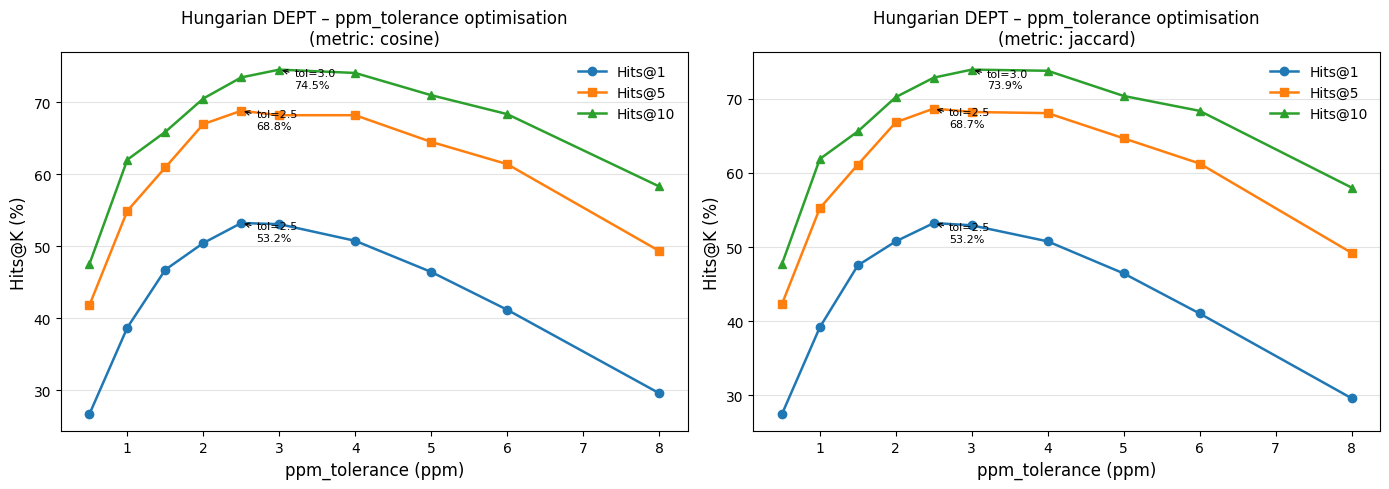

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
markers = ["o", "s", "^"]

for ax, metric in zip(axes, METRICS):
    for k, marker in zip(K_VALUES, markers):
        col = f"Hits@{k} {metric} (%)"
        ax.plot(
            summary_df.index,
            summary_df[col],
            marker=marker,
            label=f"Hits@{k}",
            linewidth=1.8,
        )
        # Annotate the optimal point
        best_tol = summary_df[col].idxmax()
        best_val = summary_df[col].max()
        ax.annotate(
            f"tol={best_tol:.1f}\n{best_val:.1f}%",
            xy=(best_tol, best_val),
            xytext=(best_tol + 0.2, best_val - 2.5),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8),
        )

    ax.set_xlabel("ppm_tolerance (ppm)", fontsize=12)
    ax.set_ylabel("Hits@K (%)", fontsize=12)
    ax.set_title(f"Hungarian DEPT – ppm_tolerance optimisation\n(metric: {metric})", fontsize=12)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.35)

fig.tight_layout()

fig_path = OPT_DIR / "tol_sweep_hits_at_k.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure saved → {fig_path}")
plt.show()

## 8 · Identify optimal `ppm_tolerance` per metric and K

In [9]:
print("Optimal ppm_tolerance per metric / K:")
for metric in METRICS:
    print(f"\n  {metric}:")
    for k in K_VALUES:
        col = f"Hits@{k} {metric} (%)"
        best_tol = summary_df[col].idxmax()
        best_val = summary_df[col].max()
        print(f"    Hits@{k:2d}: tol = {best_tol:.1f} ppm  →  {best_val:.2f}%")

Optimal ppm_tolerance per metric / K:

  cosine:
    Hits@ 1: tol = 2.5 ppm  →  53.24%
    Hits@ 5: tol = 2.5 ppm  →  68.83%
    Hits@10: tol = 3.0 ppm  →  74.54%

  jaccard:
    Hits@ 1: tol = 2.5 ppm  →  53.24%
    Hits@ 5: tol = 2.5 ppm  →  68.67%
    Hits@10: tol = 3.0 ppm  →  73.92%
